In [1]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt

from recommenders.models.sar import SAR
from recommenders.evaluation.python_evaluation import (
    rmse, mae, rsquared, exp_var, 
    precision_at_k, recall_at_k, ndcg_at_k, map_at_k
)
from recommenders.datasets.python_splitters import python_stratified_split
from recommenders.models.fastai.fastai_utils import cartesian_product, score

from fastai.callback.tracker import SaveModelCallback
from fastai.tabular.all import (
    TabularDataLoaders, Categorify, FillMissing, Normalize,
    CategoryBlock, RegressionBlock, tabular_learner,
    accuracy, rmse as fastai_rmse
)
from fastai.collab import CollabDataLoaders, collab_learner

c:\Src\NeoLeitura\.venv\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.1.0)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(
c:\Src\NeoLeitura\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
desconsidera_reviews_zerados = True
minimo_reviews = 4
idade_maxima = 110 

In [3]:
# Download do dataset
path = kagglehub.dataset_download("arashnic/book-recommendation-dataset")
print("Caminho do dataset:", path)

Caminho do dataset: C:\Users\noise\.cache\kagglehub\datasets\arashnic\book-recommendation-dataset\versions\3


In [4]:
df_books = pd.read_csv(path+'\\Books.csv', encoding='utf-8')
df_ratings = pd.read_csv(path+'\\Ratings.csv')
df_users = pd.read_csv(path+'\\Users.csv')

C:\Users\noise\AppData\Local\Temp\ipykernel_19100\2108678914.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df_books = pd.read_csv(path+'\\Books.csv', encoding='utf-8')


In [5]:
# transformações do data set de livros

def transformation_books(df):
    df["Book-Title"] = df["Book-Title"].str.lower().str.strip()
    df["Book-Author"] = df["Book-Author"].str.lower().str.strip()
    df["Book-Author"] = df["Book-Author"].str.lower().str.strip()

    
    df["Year-Of-Publication"] = pd.to_numeric(df["Year-Of-Publication"], errors='coerce')

    invalid_mask = df["Year-Of-Publication"].isna() | (df["Year-Of-Publication"] == 0)
    
    print(f'Total de livros no dataset: {len(df)}')
    print(f'Número de livros com ano inválido: {invalid_mask.sum()}')

    # Criar subset apenas com anos válidos para busca mais rápida
    df_valid = df[~invalid_mask].copy()
    
    # Pré-calcular: ano mínimo por título + autor (Regra 1)
    year_by_title_author = df_valid.groupby(['Book-Title', 'Book-Author'])['Year-Of-Publication'].min().reset_index()
    year_by_title_author.rename(columns={'Year-Of-Publication': 'year_from_title'}, inplace=True)
    
    # Pré-calcular: ano médio por autor (Regra 2)
    year_by_author = df_valid.groupby('Book-Author')['Year-Of-Publication'].mean().reset_index()
    year_by_author.rename(columns={'Year-Of-Publication': 'year_from_author'}, inplace=True)
    
    # Fazer merge para preencher valores ausentes
    df = df.merge(year_by_title_author, on=['Book-Title', 'Book-Author'], how='left')
    df = df.merge(year_by_author, on='Book-Author', how='left')
    
    # Aplicar regras em cascata (vetorizado, sem loop!)
    # Regra 1: usar year_from_title quando disponível
    df.loc[invalid_mask & df['year_from_title'].notna(), 'Year-Of-Publication'] = df.loc[invalid_mask & df['year_from_title'].notna(), 'year_from_title']
    
    # Regra 2: usar year_from_author quando regra 1 não encontrou (year_from_title é NaN)
    df.loc[invalid_mask & df['year_from_title'].isna() & df['year_from_author'].notna(), 'Year-Of-Publication'] = df.loc[invalid_mask & df['year_from_title'].isna() & df['year_from_author'].notna(), 'year_from_author']
    
    # Regra 3: Preencher restante com 0 (quando nenhuma das regras anteriores funcionou)
    df.loc[invalid_mask & df['year_from_title'].isna() & df['year_from_author'].isna(), 'Year-Of-Publication'] = 0
    
    # Remover colunas auxiliares e converter para inteiro
    df.drop(columns=['year_from_title', 'year_from_author'], inplace=True)
    df["Year-Of-Publication"] = df["Year-Of-Publication"].astype(int)
    
    return df

def transformation_users(df):
    df["Location"] = df["Location"].str.lower().str.strip()
    mediana_idade = df["Age"].median()
    df["Age"] = df["Age"].fillna(mediana_idade)
    #Alguns casos com pessoas com mais de 200 anos 
    
    df.loc[df["Age"] > idade_maxima, "Age"] = idade_maxima

    return df

df_books = transformation_books(df_books)
df_users = transformation_users(df_users)

Total de livros no dataset: 271360
Número de livros com ano inválido: 4621


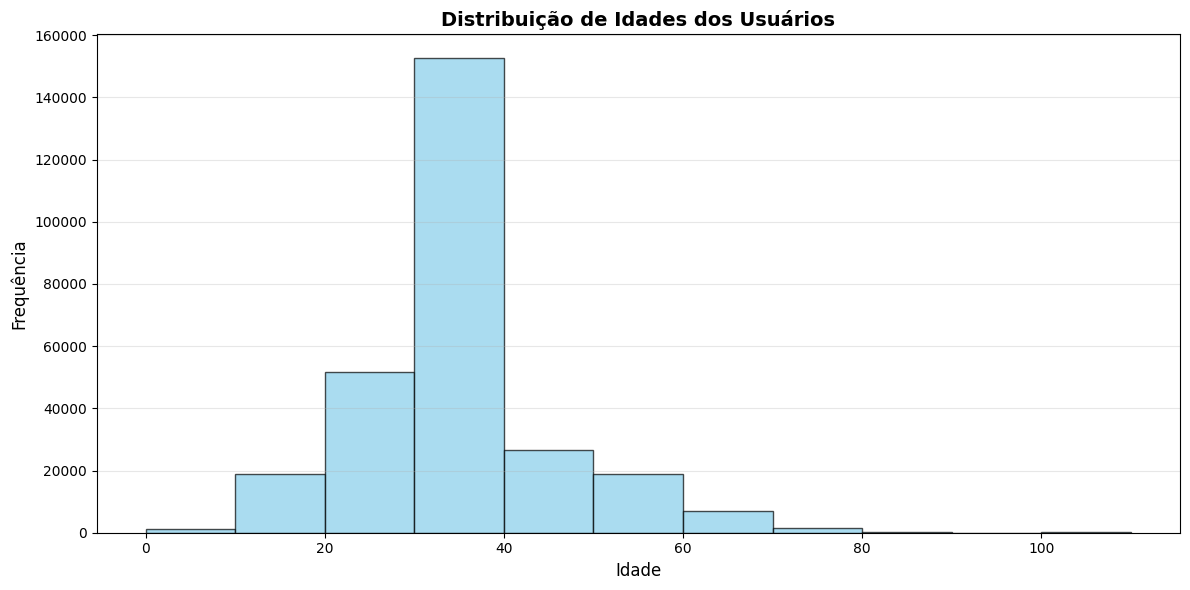

Número total de usuários: 278858
usuários com reviews: 105283


In [6]:
# Análise da distribuição de idades dos usuários

plt.figure(figsize=(12, 6))
plt.hist(df_users['Age'], bins=range(0, int(df_users['Age'].max()) + 10, 10), 
         edgecolor='black', color='skyblue', alpha=0.7)
plt.xlabel('Idade', fontsize=12)
plt.ylabel('Frequência', fontsize=12)
plt.title('Distribuição de Idades dos Usuários', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

df_users['Age'].describe()

print(f'Número total de usuários: {len(df_users)}')
print(f'usuários com reviews: {(df_users["User-ID"].isin(df_ratings["User-ID"].unique())).sum()}')

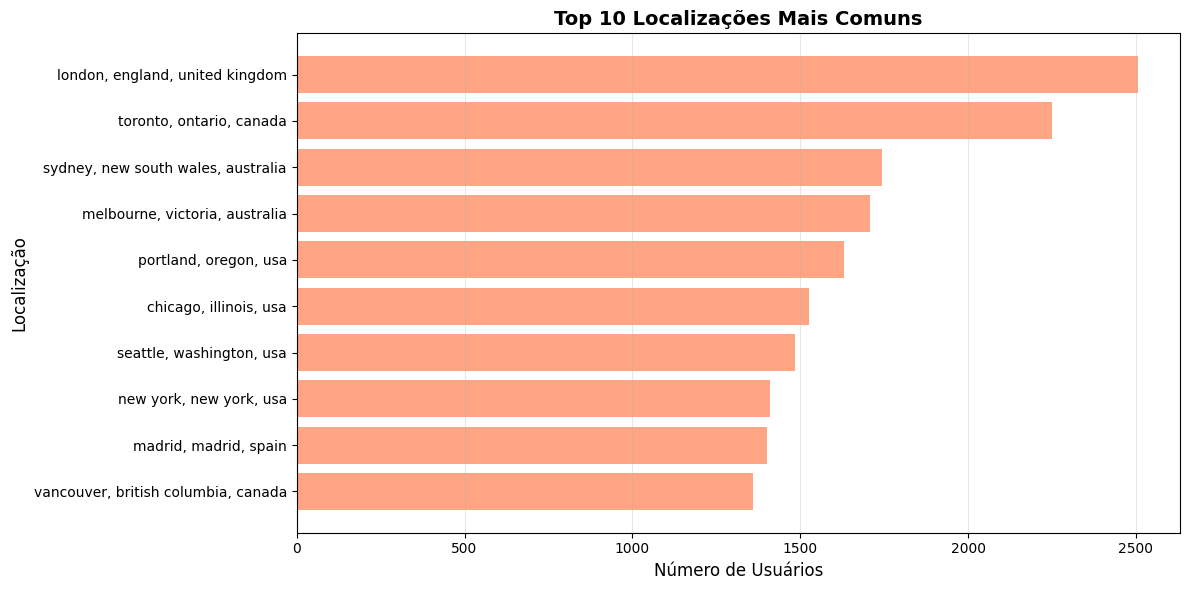

In [7]:
# Análise das 10 localizações mais comuns

top_10_locations = df_users['Location'].value_counts().head(10)

plt.figure(figsize=(12, 6))
plt.barh(range(len(top_10_locations)), top_10_locations.values, color='coral', alpha=0.7)
plt.yticks(range(len(top_10_locations)), top_10_locations.index)
plt.xlabel('Número de Usuários', fontsize=12)
plt.ylabel('Localização', fontsize=12)
plt.title('Top 10 Localizações Mais Comuns', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()  # localização mais comum no topo
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


Total de ratings com nota 0: 716,109
Percentual: 62.28%
Total geral de avaliações: 1,149,780



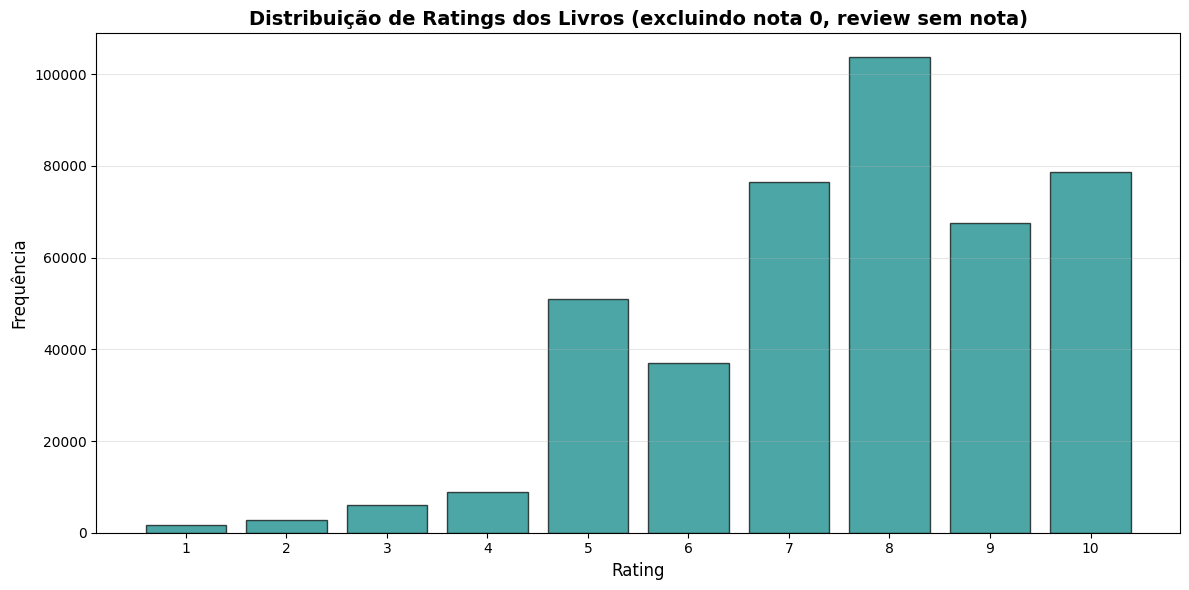

In [8]:
# Análise da distribuição de ratings

rating_counts = df_ratings['Book-Rating'].value_counts().sort_index()

total_ratings = len(df_ratings)
ratings_zerados = rating_counts.get(0, 0)
percentual_zero = (ratings_zerados / total_ratings) * 100

print(f"Total de ratings com nota 0: {ratings_zerados:,}")
print(f"Percentual: {percentual_zero:.2f}%")
print(f"Total geral de avaliações: {total_ratings:,}\n")

# Gráfico sem considerar nota 0
rating_counts_sem_zero = rating_counts[rating_counts.index != 0]

plt.figure(figsize=(12, 6))
plt.bar(rating_counts_sem_zero.index, rating_counts_sem_zero.values, color='teal', alpha=0.7, edgecolor='black')
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Frequência', fontsize=12)
plt.title('Distribuição de Ratings dos Livros (excluindo nota 0, review sem nota)', fontsize=14, fontweight='bold')
plt.xticks(range(1, 11))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


In [9]:
## análise exploratória e filtros para manter apenas usuários com registros suficientes para avaliação de recomendações

reviews_users = df_ratings["User-ID"].value_counts()



print(f'Total de usuários: {len(reviews_users)}')
print(f'Número de usuários com pelo menos {minimo_reviews} avaliações: {len(reviews_users[reviews_users >= minimo_reviews])}')

usuarios_filtrados = reviews_users[reviews_users >= minimo_reviews].index

df_ratings_filtered = df_ratings[df_ratings["User-ID"].isin(usuarios_filtrados)].copy()

if desconsidera_reviews_zerados:
    df_ratings_filtered = df_ratings_filtered[df_ratings_filtered["Book-Rating"] > 0]


Total de usuários: 105283
Número de usuários com pelo menos 4 avaliações: 27081


In [10]:
# unificação dos datasets para recomendação
df_user_ranting = df_users.merge(df_ratings_filtered, on="User-ID", how="inner")
df_desnormalizado = df_user_ranting.merge(df_books, on="ISBN", how="inner")
df_desnormalizado = df_desnormalizado.drop(columns=['Image-URL-S', 'Image-URL-M', 'Image-URL-L'])
df_desnormalizado = df_desnormalizado.dropna()

In [11]:
# Separando dados de treino x teste de maneira proporcional
df_train, df_test = python_stratified_split(
    df_desnormalizado, 
    ratio=0.75, 
    col_user='User-ID', 
    col_item='ISBN'
)

Buscando melhor learning rate...


<div></div>

SuggestedLRs(valley=0.0014454397605732083)

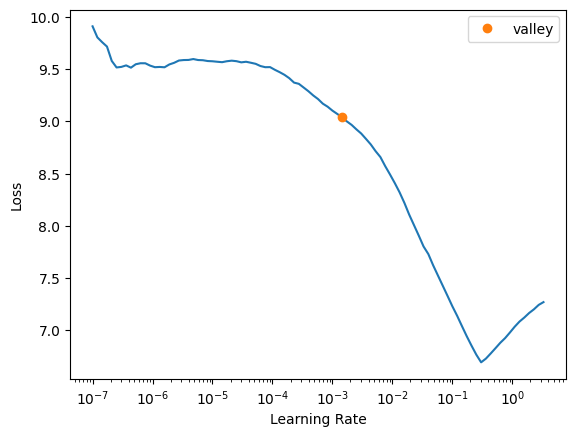

In [12]:


#1. Preparar colunas de features 
cat_cols  = ['Book-Author', 'Publisher', 'Location']   # features categóricas
cont_cols = ['Year-Of-Publication', 'Age']             # features numéricas

# Garantir tipos corretos
df_train['User-ID'] = df_train['User-ID'].astype(str)
df_test['User-ID']  = df_test['User-ID'].astype(str)

#2. Construir DataLoaders
dls = TabularDataLoaders.from_df(
    df_train,
    path='.',
    y_names='Book-Rating',
    y_block=RegressionBlock(),
    cat_names=['User-ID', 'ISBN'] + cat_cols,
    cont_names=cont_cols,
    procs=[Categorify, FillMissing, Normalize],
    valid_idx=list(range(len(df_train) - int(len(df_train) * 0.1), len(df_train))),
    bs=1024
)

#3. Criar e treinar modelo
learn = tabular_learner(
    dls,
    layers=[256, 128, 64],  # camadas ocultas
    y_range=(1, 10),        # escala de rating
    metrics=fastai_rmse
)

print("Buscando melhor learning rate...")
learn.lr_find()

In [ ]:
# treinamento do modelo, considerando 5 épocas e salvando o melhor modelo baseado na perda de informação na validação (valid_loss)
learn.fit_one_cycle(5, lr_max=1e-3, cbs=[SaveModelCallback(monitor='valid_loss')] )

epoch,train_loss,valid_loss,_rmse,time
0,3.443185,3.636552,1.906975,03:43
1,1.951117,3.615823,1.901532,03:30
2,1.417562,3.570560,1.889593,03:11
3,0.980450,3.646004,1.909451,03:03
4,0.795164,3.632215,1.905837,02:56


Better model found at epoch 0 with valid_loss value: 3.636552333831787.
Better model found at epoch 1 with valid_loss value: 3.6158227920532227.
Better model found at epoch 2 with valid_loss value: 3.570559501647949.


In [ ]:
#predições no dataframe de testes
df_test_copy = df_test.copy()
df_test_copy['User-ID'] = df_test_copy['User-ID'].astype(str)

# Preparar dados de teste no formato do fastai
test_dl = learn.dls.test_dl(df_test_copy)
preds, _ = learn.get_preds(dl=test_dl)

df_test_copy['prediction'] = preds.squeeze().numpy()

# métrica s de validação
eval_rmse = rmse(df_test_copy, df_test_copy, 
                  col_prediction='prediction', col_rating='Book-Rating',
                  col_user='User-ID', col_item='ISBN')

top_k_preds = df_test_copy.sort_values(['User-ID', 'prediction'], ascending=[True, False])
top_k_preds = top_k_preds.groupby('User-ID').head(10)

metrics = {
    "RMSE"       : eval_rmse,
    "Precision@10": precision_at_k(df_test_copy, top_k_preds, col_user='User-ID', col_item='ISBN', col_rating='Book-Rating', k=10),
    "Recall@10"  : recall_at_k(df_test_copy, top_k_preds, col_user='User-ID', col_item='ISBN', col_rating='Book-Rating', k=10),
    "NDCG@10"    : ndcg_at_k(df_test_copy, top_k_preds, col_user='User-ID', col_item='ISBN', col_rating='Book-Rating', k=10),
}

print("Métricas de Avaliação:")
for name, val in metrics.items():
    print(f"  {name}: {val:.4f}")

Métricas de Avaliação:
  RMSE: 1.7706
  Precision@10: 0.2905
  Recall@10: 0.9654
  NDCG@10: 1.0000


In [ ]:
# recomendações para um usuário específico
user_id = '154176'

# Livros ainda não lidos pelo usuário
isbn_vistos   = set(df_desnormalizado[df_desnormalizado['User-ID'] == int(user_id)]['ISBN'])
isbn_nao_visto = df_books[~df_books['ISBN'].isin(isbn_vistos)].copy()

# Montar DataFrame para predição
isbn_nao_visto['User-ID'] = user_id
isbn_nao_visto = isbn_nao_visto.merge(
    df_users[['User-ID', 'Location', 'Age']],
    left_on='User-ID', right_on=df_users['User-ID'].astype(str),
    how='left'
).drop(columns=['key_0'], errors='ignore')

pred_dl = learn.dls.test_dl(isbn_nao_visto)
preds_new, _ = learn.get_preds(dl=pred_dl)
isbn_nao_visto['prediction'] = preds_new.squeeze().numpy()

top10 = isbn_nao_visto.nlargest(10, 'prediction')[['Book-Title', 'Book-Author', 'Publisher', 'Year-Of-Publication', 'prediction']]
print(f"Top 10 recomendações para usuário {user_id}:")
top10

Top 10 recomendações para usuário 154176:


,Book-Title,Book-Author,Publisher,Year-Of-Publication,prediction
180412,i have to see this (jesse adventure series),richard thompson,Annick Press,1988,9.907014
117835,coming up with the goods: journeys through britain by freight train,michael pearson,J M Pearson &amp; Son / Wayzgoose,2000,9.905544
12801,betsy and tacy go downtown (betsy-tacy),maud hart lovelace,HarperTrophy,2000,9.889397
12758,"the two towers (the lord of the rings, part 2)",j. r. r. tolkien,Houghton Mifflin Company,1999,9.887033
180409,the night walker,richard thompson,Fitzhenry &amp; Whiteside Limited,2003,9.872169
205495,a fortune-teller told me: earthbound travels in the far east,tiziano terzani,Three Rivers Press (CA),2002,9.859460
18527,before i say goodbye,ruth picardie,Penguin Uk,1999,9.856048
146539,el hombre en busca de sentido,viktor emil frankl,Herder &amp; Herder,1998,9.852407
31423,"god, creation, and tools for life",sylvia browne,Hay House,2000,9.851173
30205,videohound's golden movie retriever 2001,jim craddock,Gale Group,2000,9.849400
